<center><h1>Brun_Antonin_HW2</h1></center>
<br>
<br>

Name: Antonin Brun
<br>
Github Username: antoninbrun
<br>
USC ID: 4845542050

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
!pip install -r requirements.txt

In [2]:
from statsmodels.graphics.regressionplots import plot_fit
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
import seaborn as sns
import pandas as pd
import numpy as np
import math
import openpyxl

Get the Cycle Power Plant Data Set

In [3]:
data_path = 'CCPP/Folds5x2_pp.xlsx'

# only use first sheet
df = pd.read_excel(data_path, sheet_name=0)

### (b) Exploring the data

#### i. rows and columns

In [4]:
df

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


There are **9568 rows** and **5 columns** in this dataset. 

The rows represent all the instances of this dataset, and the columns represent its FEATURES (a set of hourly average ambient variables): <br>
Temperature (AT), Ambient Pressure (AP), Relative Humidity (RH) and Exhaust Vacuum (V) to predict the net hourly electrical
energy output (PE) of the power plant. Specficially, AT, AP, RH, and V are the **independent variables**; while PE is the **dependent variable**.

#### ii. pairwise scatterplots of all the varianbles

In [5]:
df.columns

Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='str')

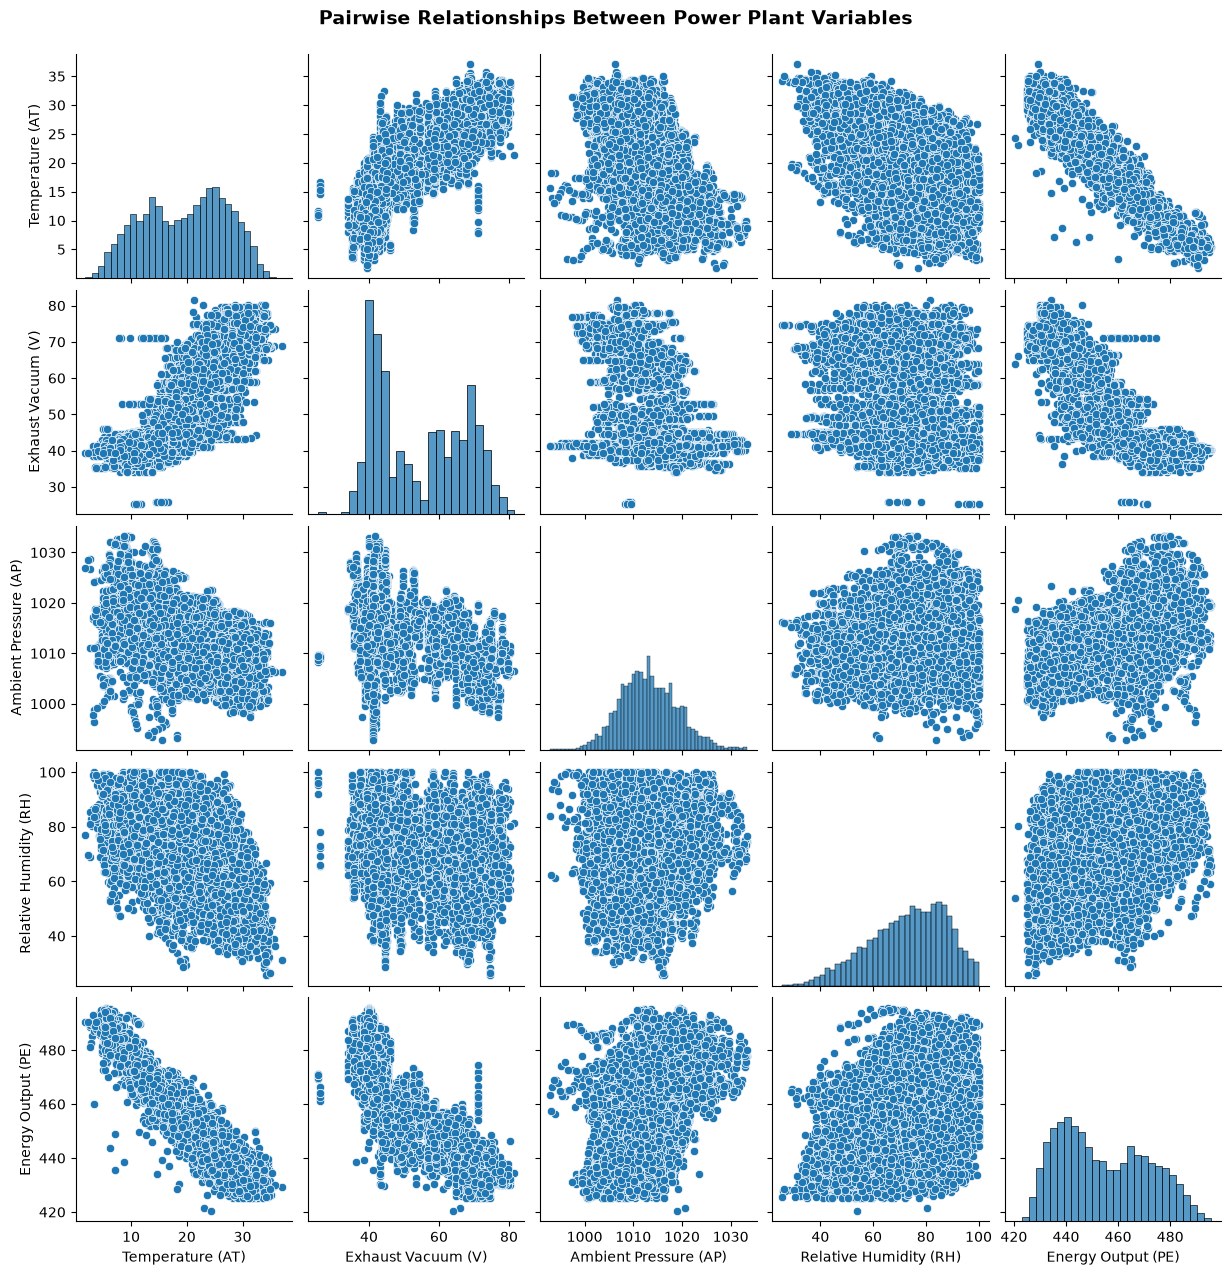

In [6]:
FEATURES = ['AT', 'V', 'AP', 'RH', 'PE']

feature_names = {
    'AT': 'Temperature (AT)',
    'V': 'Exhaust Vacuum (V)',
    'AP': 'Ambient Pressure (AP)',
    'RH': 'Relative Humidity (RH)',
    'PE': 'Energy Output (PE)'
}

plot_df = df[FEATURES].rename(columns=feature_names)

pairwise_scatterplot_fig = sns.pairplot(plot_df)

pairwise_scatterplot_fig.fig.suptitle(
    "Pairwise Relationships Between Power Plant Variables",
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.show()

First, looking at **distributions** only, we note that: 
- AP appears to be normally distributed, 
- RH has more of skewed distribution, 
- while PE, V, and AT show multiple peaks rather than a uniform distribution pattern. 
<br>

Then, for **pairwise relationships**: 
- **PE and AT**, **PE and V** seem to covary: specifically with **increasing AT and V, PE seems to decrease**. 
- Similarly, **AT and V** also appear to covary where **increasing AT** seems to be linked with **increasing V**. 
- The relationship between **P and AT**, as well as **AP and V**, may show some relationship between variables, although these patterns are less from visual inspection alone.


#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [7]:
summary_stats = pd.DataFrame({
    'Mean': df.mean(),
    'Median': df.median(),
    'Range': df.max() - df.min(),
    'Q1': df.quantile(0.25),
    'Q3': df.quantile(0.75),
    'IQR': df.quantile(0.75) - df.quantile(0.25)
}).round(2)

summary_stats

,Mean,Median,Range,Q1,Q3,IQR
AT,19.65,20.34,35.30,13.51,25.72,12.21
V,54.31,52.08,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,74.60,63.33,84.83,21.50
PE,454.37,451.55,75.50,439.75,468.43,28.68


### (c) Simple Linear Regression

For each predictor, fit a simple linear regression model to predict the response.
Describe your results. In which of the models is there a statistically significant
association between the predictor and the response? Create some plots to back
up your assertions. Are there any outliers that you would like to remove from
your data for each of these regression tasks?

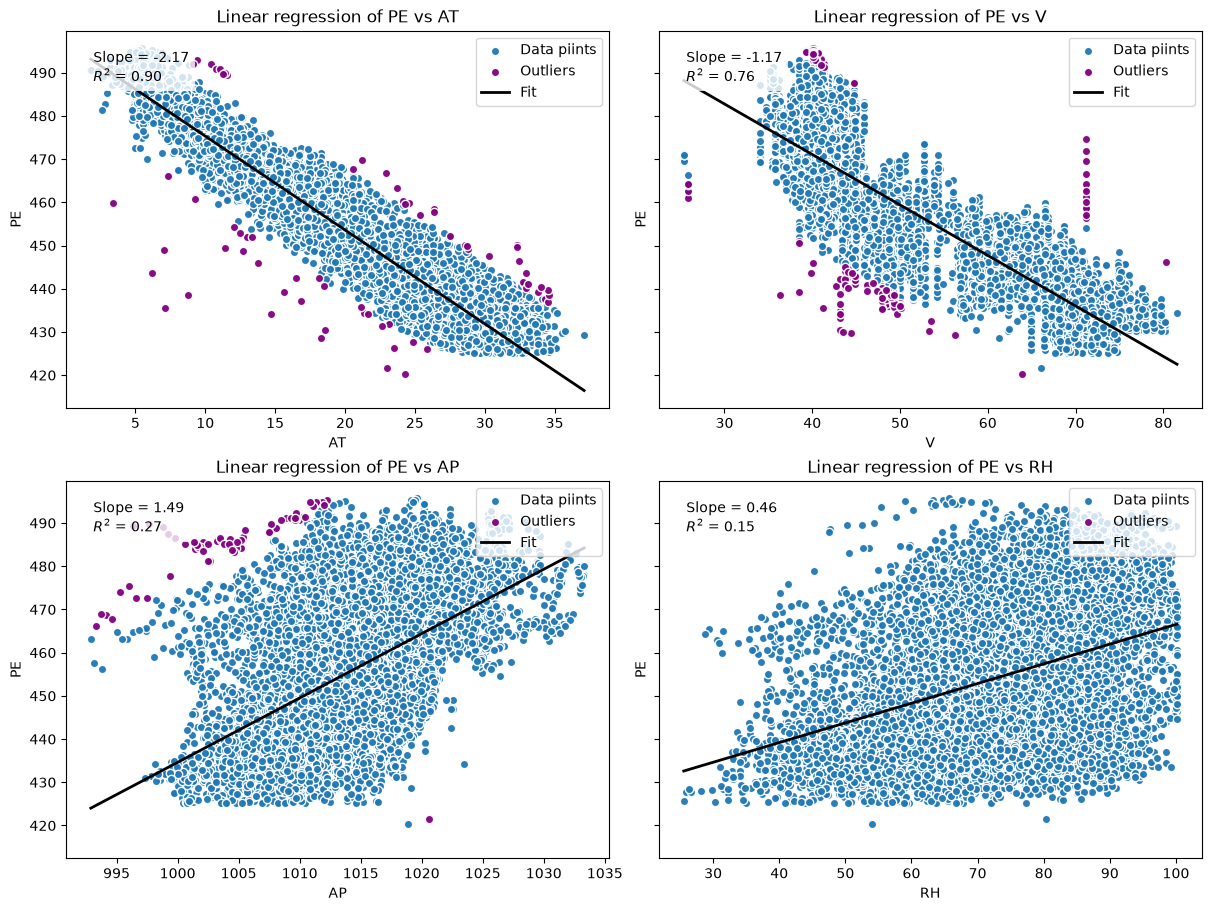

,Predictor,Estimate,Std. Err,t value,p-value,R^2,#Outliers,%Outliers
0,AT,-2.17,0.010,-291.72,0.000e+00,0.900,70,0.73%
1,V,-1.17,0.010,-172.40,0.000e+00,0.760,140,1.46%
2,AP,1.49,0.030,59.30,0.000e+00,0.270,63,0.66%
3,RH,0.46,0.010,41.40,0.000e+00,0.150,0,0.00%


In [8]:
# set subdataset and FEATURES
RESPONSE = 'PE'
PREDICTORS = FEATURES.copy()
PREDICTORS.remove(RESPONSE)

sub = df[PREDICTORS + [RESPONSE]].dropna().copy()
y = sub[RESPONSE].to_numpy()

# set figure for plotting multiple graphs
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True, constrained_layout=True)
axes = axes.ravel()
# set range for outlier removal using [-1.5IQR, 1.5IQR] as seen in class
k_IQR = 1.5

summary_rows = []

for ax, xcol in zip(axes, PREDICTORS):
    x = sub[xcol].to_numpy()

    X = sm.add_constant(x, has_constant='add')
    model = sm.OLS(y, X).fit()
    # residuals = model.resid
    residuals = y - model.predict(X)

    # IQR rnge filtering
    q1, q3 = np.percentile(residuals, [25, 75])
    IQR = q3 - q1
    lower = q1 - k_IQR * IQR
    upper = q3 + k_IQR * IQR
    out_mask = (residuals < lower) | (residuals > upper)

    summary_rows.append({
        "Predictor": xcol,
        "Estimate":  float(model.params[1].round(2)),
        "Std. Err":  float(model.bse[1].round(2)),
        "t value":   float(model.tvalues[1].round(2)),
        "p-value":   float(model.pvalues[1]),
        "R^2":       float(model.rsquared.round(2)),
        "#Outliers": int(out_mask.sum()),
        "%Outliers": int(out_mask.sum())/len(sub)
    })

    # plots
    ax.scatter(x[~out_mask], y[~out_mask], edgecolors='white', alpha=0.95, label='Data piints')
    ax.scatter(x[out_mask],  y[out_mask], edgecolors='white', alpha=0.95, color='purple', label='Outliers')

    x_min, x_max = np.min(x), np.max(x)
    y_min = model.params[0] + model.params[1] * x_min
    y_max = model.params[0] + model.params[1] * x_max
    ax.plot([x_min, x_max], [y_min, y_max], color='black', linewidth=2, label='Fit')

    # annotate slope and R^2 for good measure
    slope = model.params[1]

    ax.text(
        0.05, 0.95,
        f"Slope = {slope:.2f}\n$R^2$ = {model.rsquared:.2f}",
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=10,
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
    )

    ax.set_xlabel(xcol)
    ax.set_ylabel(RESPONSE)
    
    ax.set_title(f'Linear regression of {RESPONSE} vs {xcol}')
    ax.legend(loc='upper right')


plt.show()

rows_df = pd.DataFrame(summary_rows).sort_values('p-value')
# rows_df
rows_df = pd.DataFrame(summary_rows).sort_values('p-value')

rows_df.style.format({
    "Estimate": "{:.2f}",
    "Std. Err": "{:.3f}",
    "t value": "{:.2f}",
    "p-value": "{:.3e}",
    "R^2": "{:.3f}",
    "%Outliers": "{:.2%}"
})

All p-values are < 0.001 --> so everything is statistically siginificant. 
<br>

- **AT --> PE**: statistically significant negative association
- **V --> PE**: statistically significant negative association
- **AP --> PE**: statistically significant positive association
- **RH --> PE**: statistically significant positive association

### (d) Multiple Regression
Fit a multiple regression model to predict the response using all of the predictors.
Describe your results. For which predictors can we reject the null hypothesis
H0 : βj = 0?

In [9]:
X = sub[PREDICTORS]
X = sm.add_constant(X)

y = sub[RESPONSE]

# fit for all models
multiple_model = sm.OLS(y, X).fit()

print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:46:24   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

We can reject the null hypothesis for every predictor since they all reached a p-value <0.001.
<br>

- AT is negatively associated with PE (t=-129.342, p<0.001)
- V is negatively associated with PE (t=-32.122, p<0.001)
- AP is positively associated with PE (t=6.564, p<0.001)
- RH is negatively associated with PE (t=-37.918, p<0.001)

### (e) 1c Compare to 1d

In [10]:
# coefficients from simple linear regressions (1c)
simple_coefficients = rows_df.set_index("Predictor")["Estimate"]

# coefficients from multiple linear regression (1d)
multiple_coefficients = multiple_model.params.drop("const")

# combine into one dataframe
coefficients_compare = pd.DataFrame({
    "Simple regression": simple_coefficients,
    "Multiple regression": multiple_coefficients
})

coefficients_compare

,Simple regression,Multiple regression
AT,-2.17,-1.977513
V,-1.17,-0.233916
AP,1.49,0.062083
RH,0.46,-0.158054


Some difference in coefficients! p-value isn't everything. What's more interesting is how AP is 25times less in the multiple regression that in the simple regression. RH flipped sign which isn't a good sign (ba dum tss). V in the simple regression is 5 fold what it is in the multiple regresion, while AT coefficients are pretty similar for both regression.
<br>

- **AT: −2.17 -> −1.98**, same sign, roughly same magnitude
- **V: −1.17 -> −0.23**, same sign, magnitude decreased by ~5X
- **AP: +1.49 -> +0.06**, same sign, magnitude decreased by ~25X
- **RH: +0.46 -> −0.16**, sign flieppd, magnitude decrease by ~3X (but irrelevant because sign flip??)
<br>
<br>

These differences occur because the simple regressions consider each predictor individually, whereas the multiple regressions estimate the association between each predictor and PE while holding the other predictors constant!! 

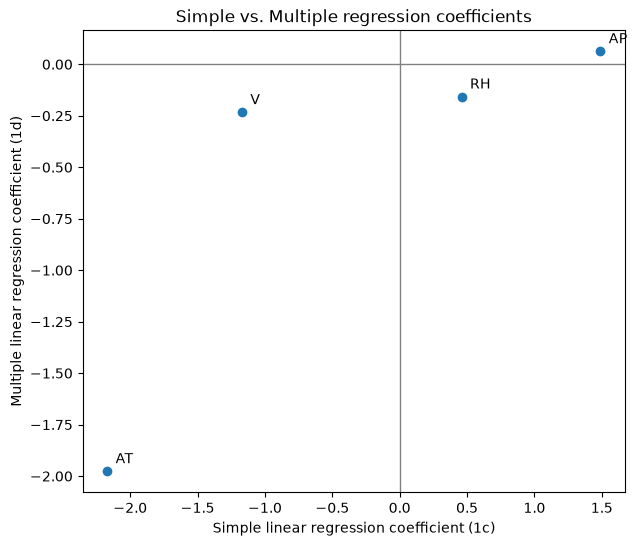

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    coefficients_compare["Simple regression"],
    coefficients_compare["Multiple regression"]
)

# label each predictor
for predictor, row in coefficients_compare.iterrows():
    ax.annotate(predictor, (row["Simple regression"], row["Multiple regression"]), xytext=(6, 6), textcoords="offset points")

ax.axhline(0, color="gray", linewidth=1)
ax.axvline(0, color="gray", linewidth=1)

ax.set_xlabel("Simple linear regression coefficient (1c)")
ax.set_ylabel("Multiple linear regression coefficient (1d)")
ax.set_title("Simple vs. Multiple regression coefficients")

plt.show()

### (f) Nonlinear Association

In [12]:
poly_results = []

for xcol in PREDICTORS:

    # center predictor for numerical stability
    x = df[[xcol]].to_numpy()
    x_centered = x - x.mean()

    y = df[RESPONSE].to_numpy()

    # generate X, X^2, X^3
    poly = PolynomialFeatures(degree=3, include_bias=False)
    X_poly = poly.fit_transform(x_centered)

    # intercept!
    X_poly = sm.add_constant(X_poly)

    # fit cubic model
    model = sm.OLS(y, X_poly).fit()

    term_names = ['Intercept', 'X', 'X^2', 'X^3']

    for i, term in enumerate(term_names):
        poly_results.append({
            'Predictor': xcol,
            'Term': term,
            'Estimate': model.params[i].round(2),
            'Std. Err': model.bse[i].round(2),
            't value': model.tvalues[i].round(2),
            'p-value': model.pvalues[i],
            'R^2': model.rsquared.round(2)
        })


poly_results_df = pd.DataFrame(poly_results)
# poly_results_df

#cleaning because p-values are in scienfitic mode and harder to read
display_poly = poly_results_df.copy()

display_poly['p-value'] = display_poly['p-value'].apply(
    lambda p: '< .001' if p < .001 else f'{p:.3f}'
)

display_poly.style.format({
    'Estimate': '{:.3f}',
    'Std. Err': '{:.3f}',
    't value': '{:.2f}',
    'R^2': '{:.3f}'
}).hide(axis='index')

Predictor,Term,Estimate,Std. Err,t value,p-value,R^2
AT,Intercept,452.710,0.070,6085.24,< .001,0.910
AT,X,-2.430,0.010,-167.16,< .001,0.910
AT,X^2,0.030,0.000,33.38,< .001,0.910
AT,X^3,0.000,0.000,22.59,< .001,0.910
V,Intercept,451.210,0.140,3124.60,< .001,0.780
V,X,-1.250,0.010,-85.72,< .001,0.780
V,X^2,0.020,0.000,24.71,< .001,0.780
V,X^3,0.000,0.000,2.46,0.014,0.780
AP,Intercept,453.080,0.180,2520.29,< .001,0.300
AP,X,1.960,0.040,50.67,< .001,0.300


There is evidence of nonlinear association between each predictor and PE. The quadratic and cubic terms were statistically significant for AT, V, and AP. For RH, the quadratic term was not significant (p = .101), but the cubic term was significant (p < .001), suggesting some evidence of nonlinearity. 
<br>

The polynomial model for AT explained the largest proportion of variation in PE (R^2 = .91), followed by V (R^2 = .78). The models for AP (R^2 = .30) and RH (R^2 = .15) explained substantially less variation in PE.

### (g) Interactions of Predictors

In [13]:
# include all term up to two-way interaction using R qriting style
interaction_model = smf.ols('PE ~ (AT + V + AP + RH)**2',data=df).fit()

print(interaction_model.summary())

p_values = interaction_model.pvalues
sig_p_values = p_values[(p_values < 0.05)]
significant_interactions = sig_p_values[ sig_p_values < 0.05]

print("\nSignificant p-values for interaction terms:")
print(significant_interactions)

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:46:24   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

Statisically significant terms: 
- V p<0.001 
- AP p=0.047 (barely!)
- RH p=0.042
- AT x V p<0.001 
- AT x RH p<0.001
- V x AP p<0.001  
- AP x RH p=0.034

<br><br>

Non-statisically significant terms: 
- AT p=0.067
- AT x HP p=0.452
- V xRH p=0.086

### (h) Improvement

In [14]:
data = df[PREDICTORS + [RESPONSE]].dropna()

# use random state to replicate results
train, test = train_test_split(data, test_size=0.30, random_state=42)

X_train = train[PREDICTORS]
X_test = test[PREDICTORS]

y_train = train[RESPONSE]
y_test = test[RESPONSE]


In [15]:
#same m,odel from 1d

X_train_linear = sm.add_constant(X_train)
X_test_linear = sm.add_constant(X_test)

linear_model = sm.OLS(y_train, X_train_linear).fit()

print(linear_model.summary())

train_pred_linear = linear_model.predict(X_train_linear)
test_pred_linear = linear_model.predict(X_test_linear)

linear_train_mse = mean_squared_error(y_train, train_pred_linear)
linear_test_mse = mean_squared_error(y_test, test_pred_linear)

print("\n\n")
print(f"Linear train MSE: {linear_train_mse:.3f}")
print(f"Linear test MSE:  {linear_test_mse:.3f}")

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 2.194e+04
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:46:24   Log-Likelihood:                -19630.
No. Observations:                6697   AIC:                         3.927e+04
Df Residuals:                    6692   BIC:                         3.930e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        467.8414     11.502     40.673      0.0

In [16]:
#run for all quadratic and remove insignificant variales while being careful of interaction terms!!!
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# use featurhs to train
feature_names = poly.get_feature_names_out(PREDICTORS)

# print(feature_names)

X_train_poly = pd.DataFrame(
    X_train_poly,
    columns=feature_names,
    index=X_train.index
)

X_test_poly = pd.DataFrame(X_test_poly, columns=feature_names,index=X_test.index)

In [17]:
# let's create a function to do that where we remove all terms >.05, but keeping all interaction terms if the interaction term is singificant, and same for quad terms --> if sig, we keep the linear term as well

"""
Return main effects required by a higher-order term --> either interaction term (e.g., 'AT V') or quadratic term (e.g., 'AT^2').
"""
def get_parents(term):
    if '^2' in term:
        return {term.replace('^2', '')}
    
    if ' ' in term:
        return set(term.split(' '))
    
    return set()

'''
This function takes in a test set X and prediction vector y, iteratively fits an OLS and removes highest insignificant term UNLESS present in a significant interaction term OR a signifcant quadratic term. 

At each iteration:
1. Fit the model using the currently retained terms
2. Identify terms with p > 0.05 (alpha)
3. Check for parent relationship calling the get_parents() function and remove only if the term is not statisticatly significant as a child/parnts
4. remove the term with the largest p-value within eligbile terms (pass parent child check)
5. Refit the model and repeat until no eligible term has p > alpha.

The function returns the final sm model output, the retained model terms, and the removed terms and their corresponding p-values
'''
def hierarchical_backward_elimination(X, y, alpha=0.05):
    terms = list(X.columns)
    removal_history = []

    while True:
        
        X_current = sm.add_constant(X[terms],has_constant='add')
        
        model = sm.OLS(y, X_current).fit()
        
        pvalues = model.pvalues.drop('const')

        # main effects that must remain because a higher-order term involving them is still in the model
        protected = set()

        for term in terms:
            protected.update(get_parents(term))

        removable = [
            term for term in terms
            if get_parents(term) or term not in protected
        ]

        insignificant = pvalues.loc[removable]
        insignificant = insignificant[insignificant > alpha]

        # stop when all removable terms are significant
        if insignificant.empty:
            break

        # remove the least significant term past child parent check
        worst_term = insignificant.idxmax()
        worst_p = insignificant.loc[worst_term]

        removal_history.append({
            'Removed term': worst_term,
            'p-value': worst_p
        })

        terms.remove(worst_term)

    # fit final model
    final_X = sm.add_constant(
        X[terms],
        has_constant='add'
    )

    final_model = sm.OLS(y, final_X).fit()

    return final_model, terms, pd.DataFrame(removal_history)


selected_model, selected_terms, removal_history = (hierarchical_backward_elimination(X_train_poly, y_train, alpha=0.05))

print("Removed terms: ", removal_history)
print("\nSelectedd terms: ", selected_terms)

Removed terms:    Removed term   p-value
0         V RH  0.867382
1          V^2  0.607733
2         V AP  0.357826

Selectedd terms:  ['AT', 'V', 'AP', 'RH', 'AT^2', 'AT V', 'AT AP', 'AT RH', 'AP^2', 'AP RH', 'RH^2']


In [18]:
# test on remainging terms!
X_train_selected = sm.add_constant(X_train_poly[selected_terms], has_constant='add')

X_test_selected = sm.add_constant(X_test_poly[selected_terms], has_constant='add')

train_pred_selected = selected_model.predict(X_train_selected)
test_pred_selected = selected_model.predict(X_test_selected)

selected_train_mse = mean_squared_error(y_train, train_pred_selected)

selected_test_mse = mean_squared_error(y_test, test_pred_selected)

# print("\n\n")
print(f"Linear train MSE: {linear_train_mse:.3f}")
print(f"Linear test MSE:  {linear_test_mse:.3f}")
# print("\n")
print(f"\nSelected train MSE: {selected_train_mse:.3f}")
print(f"Selected test MSE:  {selected_test_mse:.3f}")



Linear train MSE: 20.581
Linear test MSE:  21.240

Selected train MSE: 17.891
Selected test MSE:  18.660


Yes, we can improve our model! We've decreased our test MSE by almost 3 points. 

### (i) KNN

In [19]:
# X_train = train[PREDICTORS]
# y_train = train[RESPONSE]

# X_test = test[PREDICTORS]
# y_test = test[RESPONSE]

# X_tr = X_train
# X_te = X_test
# # make y vectors (1d arrays)
# y_tr = np.ravel(y_train)
# y_te = np.ravel(y_test)

# k_values = np.arange(1, 101)


def evaluate_knn(X_train, X_test, y_train, y_test, max_k=100):
    
    results = []

    for k in range(1, max_k + 1):

        model = KNeighborsRegressor(n_neighbors=k)
        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        results.append({
            'k': k,
            '1/k': 1 / k,
            'Train MSE': mean_squared_error(y_train, train_pred),
            'Test MSE': mean_squared_error(y_test, test_pred)
        })

    results_df = pd.DataFrame(results)

    best_idx = results_df['Test MSE'].idxmin()
    best_k = int(results_df.loc[best_idx, 'k'])

    return results_df, best_k


#testing on raw data
X_train_raw = train[PREDICTORS]
X_test_raw = test[PREDICTORS]

y_train = train[RESPONSE]
y_test = test[RESPONSE]

raw_results, best_k_raw = evaluate_knn(
    X_train_raw,
    X_test_raw,
    y_train,
    y_test
)

print("Best k for raw features:", best_k_raw)

#testing on normalised data
scaler = StandardScaler()

# fit ONLY using training data
X_train_scaled = scaler.fit_transform(X_train_raw)

# apply same transformation to test data
X_test_scaled = scaler.transform(X_test_raw)

scaled_results, best_k_scaled = evaluate_knn(
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

print("Best k for normalised features:", best_k_scaled)

Best k for raw features: 5
Best k for normalised features: 4


In [20]:
best_knn_raw = raw_results.loc[raw_results['Test MSE'].idxmin()]
print("Raw results best k, train and test MSE:\n", best_knn_raw)

Raw results best k, train and test MSE:
 k             5.000000
1/k           0.200000
Train MSE    10.600769
Test MSE     15.726820
Name: 4, dtype: float64


In [21]:
best_knn_normalised = scaled_results.loc[scaled_results['Test MSE'].idxmin()]
print("Normalised results best k, train and test MSE:\n", best_knn_normalised)

Normalised results best k, train and test MSE:
 k             4.000000
1/k           0.250000
Train MSE     8.591433
Test MSE     14.305669
Name: 3, dtype: float64


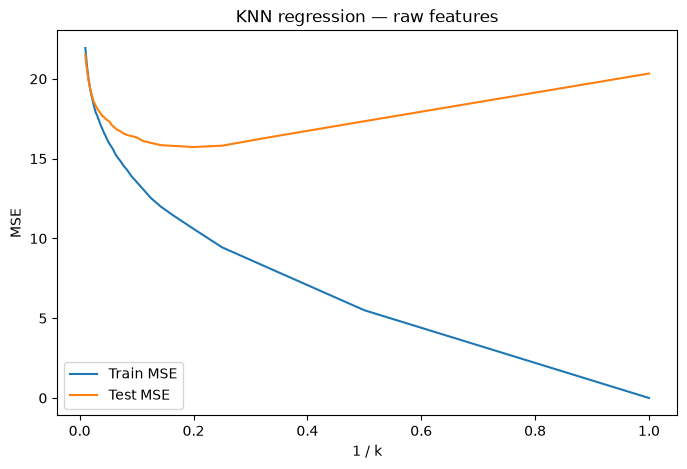

In [22]:
# raw features
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    raw_results['1/k'],
    raw_results['Train MSE'],
    label='Train MSE'
)

ax.plot(
    raw_results['1/k'],
    raw_results['Test MSE'],
    label='Test MSE'
)

ax.set_xlabel('1 / k')
ax.set_ylabel('MSE')
ax.set_title('KNN regression — raw features')
ax.legend()

plt.show()

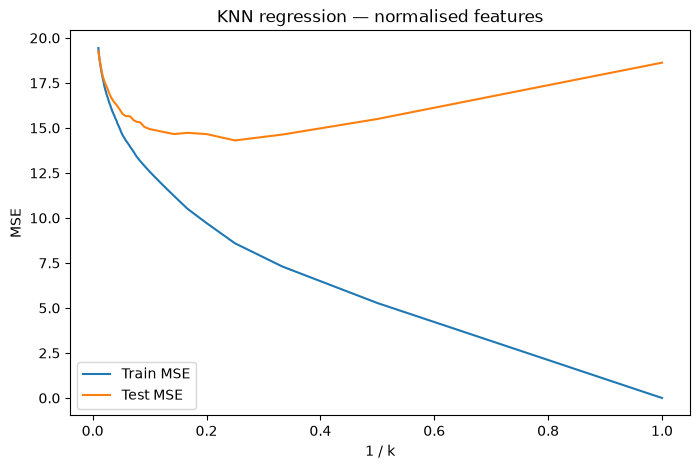

In [23]:
# normalise features
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    scaled_results['1/k'],
    scaled_results['Train MSE'],
    label='Train MSE'
)

ax.plot(
    scaled_results['1/k'],
    scaled_results['Test MSE'],
    label='Test MSE'
)

ax.set_xlabel('1 / k')
ax.set_ylabel('MSE')
ax.set_title('KNN regression — normalised features')
ax.legend()

plt.show()

### (j ) Compare KNN and Linear

In [24]:
# determine which linear regression model had the smallest test MSE (should be our latest iterative p-value removing model)
linear_models = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Regression + Interactions/Quadratics'
    ],
    'Train MSE': [
        linear_train_mse,
        selected_train_mse
    ],
    'Test MSE': [
        linear_test_mse,
        selected_test_mse
    ]
})

best_linear = linear_models.loc[linear_models['Test MSE'].idxmin()]


comparison = pd.DataFrame({
    'Model': [
        best_linear['Model'],
        f'KNN raw (k={int(best_knn_raw["k"])})',
        f'KNN normalised (k={int(best_knn_normalised["k"])})'
    ],
    'Train MSE': [
        best_linear['Train MSE'],
        best_knn_raw['Train MSE'],
        best_knn_normalised['Train MSE']
    ],
    'Test MSE': [
        best_linear['Test MSE'],
        best_knn_raw['Test MSE'],
        best_knn_normalised['Test MSE']
    ]
})

comparison = comparison.sort_values('Test MSE')

comparison.style.format({
    'Train MSE': '{:.3f}',
    'Test MSE': '{:.3f}'
}).hide(axis='index')

Model,Train MSE,Test MSE
KNN normalised (k=4),8.591,14.306
KNN raw (k=5),10.601,15.727
Regression + Interactions/Quadratics,17.891,18.660


The lowest test MSE is from the **KNN with normalised features** with a test MES of 14.306, against 15.727 for the *raw KNN*, and 18.660 for the *best linear model obtained in question (h)*. This may be due to the fact that KNNs can capture local non linear strucutre that might be missed by simple regressions (they tend to 'average' out though this is not the exactly right tern). Normalising the features also helped prevent larger features to dominate smaller one--like ambient pressure with values in the ~1000s against temperature with values in the ~25. This goes back to (b) where we explore the data, fun!


## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

**better:** large N and few predictors p --> low variance cost, a flexible model would be better to decrease bias and better 'fit' the data


### (b) The number of predictors p is extremely large, and the number of observations n is small.

**worse:** less data points, very high variance an d thus more likely to overfit! An inflexible model is more robust to overfitting

### (c) The relationship between the predictors and response is highly non-linear.

**better:** more degrees of freedom to help match the expected f shape, a flexible model would be better

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

**worse:** more random noise, which a more flexible model might overfit / high variance

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [25]:
# Funny enough I did this exercise in google sheets when I irst started to read the book, but it goes like this

df_knn = pd.DataFrame({
    'obs': [1, 2, 3, 4, 5, 6],
    'X1':  [0, 2, 0, 0, -1, 1],
    'X2':  [3, 0, 1, 1, 0, 1],
    'X3':  [0, 0, 3, 2, 1, 1],
    'Y':   ['Red', 'Red', 'Red', 'Green', 'Green', 'Red']
})

df_knn

,obs,X1,X2,X3,Y
0,1,0,3,0,Red
1,2,2,0,0,Red
2,3,0,1,3,Red
3,4,0,1,2,Green
4,5,-1,0,1,Green
5,6,1,1,1,Red


In [26]:
# we compare against point at 0,0,0 (center of coordinate system)
new_point = np.array([0, 0, 0])

df_knn['Euclidean Distance'] = np.sqrt(
    (df_knn['X1'] - new_point[0])**2 +
    (df_knn['X2'] - new_point[1])**2 +
    (df_knn['X3'] - new_point[2])**2
).round(2)

df_knn

,obs,X1,X2,X3,Y,Euclidean Distance
0,1,0,3,0,Red,3.00
1,2,2,0,0,Red,2.00
2,3,0,1,3,Red,3.16
3,4,0,1,2,Green,2.24
4,5,-1,0,1,Green,1.41
5,6,1,1,1,Red,1.73


### (b) What is our prediction with K = 1? Why?

In [27]:
nearest_k1 = df_knn.nsmallest(1, 'Euclidean Distance')

nearest_k1

,obs,X1,X2,X3,Y,Euclidean Distance
4,5,-1,0,1,Green,1.41


**Green!** because lowest euclidian distance of 1.41, as seen above.

### (c) What is our prediction with K = 3? Why?

In [28]:
nearest_3 = df_knn.nsmallest(3, 'Euclidean Distance')

nearest_3

,obs,X1,X2,X3,Y,Euclidean Distance
4,5,-1,0,1,Green,1.41
5,6,1,1,1,Red,1.73
1,2,2,0,0,Red,2.00


In [29]:
fraction = nearest_3['Y'].value_counts(normalize=True)
print(fraction.round(2))

Y
Red      0.67
Green    0.33
Name: proportion, dtype: float64


**Red!** highest proportion (majority voting) amongst three lowest euclidian  when k==3

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

If the Bayes decision boundary is highly nonlinear, we would generally expect a **small k** to perform better --> more flexible decision boundaries that can adapt to local nonlinear patterns, whereas large k values smooth over those patterns and may underfit the true boundary (Figure 2.16 in ISLR)